# 01 — Exploratory Data Analysis (EDA)

Notebook ini melakukan eksplorasi awal dataset AQI Bangladesh untuk memahami distribusi data, pola temporal, korelasi antar polutan, dan kebutuhan pembersihan data.

## Input
- `../AQI Bangladesh.csv` — dataset mentah (1,048,551 baris × 13 kolom)
  *(Atau diunduh dari Google Drive jika file lokal tidak tersedia.)*

## Insight yang Dieksplorasi
| Section | Topik |
|---|---|
| 3.1 | Statistik deskriptif, skewness, kurtosis |
| 3.2 | Missing value analysis (`carbon_dioxide` 73.85% missing) |
| 3.3 | Distribusi kota & jumlah record per kota |
| 3.4 | Rentang waktu dataset (2000–2025) |
| 3.5 | Distribusi & histogram setiap polutan |
| 3.6 | Deteksi nilai negatif (NO₂ dan Ozone) |
| 3.7 | Deteksi outlier metode IQR |
| 3.8 | Matriks korelasi antar polutan dan AQI |
| 3.9 | Tren AQI harian per kota |
| 3.10 | Pola temporal (per jam, per bulan, per hari) |
| 3.11 | Distribusi kategori AQI |

**Catatan:** Notebook ini murni untuk eksplorasi — tidak mengubah atau menyimpan data apapun.
**Notebook berikutnya:** `02_cleaning.ipynb`

---
*Steven Lie Wibowo · Tristian Yosa · Faiz Naufal Huda · Daffa Naufal Mumtaz — Kelompok 7*

## 1. Import Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
from scipy import stats
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# Setting Global
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 2. Load Dataset

In [2]:
# Coba muat dari file lokal terlebih dahulu, fallback ke Google Drive
file_local = '../AQI Bangladesh.csv'

if os.path.exists(file_local):
    print("Memuat dataset dari file lokal...")
    df = pd.read_csv(file_local)
else:
    print("File lokal tidak ditemukan — mengunduh dari Google Drive...")
    file_id = "1I7dtUfl3owj8kdwwwezEXtMBF2627_gk"
    url = f"https://drive.google.com/uc?id={file_id}"
    df = pd.read_csv(url)

print(f'Ukuran Dataset: {df.shape[0]:,} baris × {df.shape[1]} kolom')

Memuat dataset dari file lokal...
Ukuran Dataset: 1,048,551 baris × 13 kolom


In [3]:
df.head()

,city_id,city_name,lat,lon,datetime,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
0,7701354,Azimpur,23.7298,90.3854,2022-08-05T00:00,25.0000,16.7000,252.0000,NaN,18.6000,5.2000,13.0000,50.0000
1,7701354,Azimpur,23.7298,90.3854,2022-08-05T01:00,18.5000,12.3000,249.0000,NaN,18.5000,5.7000,19.0000,50.0000
2,7701354,Azimpur,23.7298,90.3854,2022-08-05T02:00,16.1000,10.9000,244.0000,NaN,18.4000,6.5000,27.0000,51.0000
3,7701354,Azimpur,23.7298,90.3854,2022-08-05T03:00,15.4000,10.3000,233.0000,NaN,17.2000,6.9000,39.0000,51.0000
4,7701354,Azimpur,23.7298,90.3854,2022-08-05T04:00,16.8000,11.3000,217.0000,NaN,14.8000,6.2000,51.0000,51.0000


In [4]:
df.tail()

,city_id,city_name,lat,lon,datetime,pm10,pm2_5,carbon_monoxide,carbon_dioxide,nitrogen_dioxide,sulphur_dioxide,ozone,aqi
1048546,1185210,Gaurnadi,22.9737,90.2238,2023-09-15T10:00,13.5000,8.2000,145.0000,NaN,1.5000,0.9000,69.0000,52.0000
1048547,1185210,Gaurnadi,22.9737,90.2238,2023-09-15T11:00,14.0000,8.6000,157.0000,NaN,2.5000,1.1000,65.0000,51.0000
1048548,1185210,Gaurnadi,22.9737,90.2238,2023-09-15T12:00,19.4000,12.1000,188.0000,NaN,4.6000,1.3000,55.0000,51.0000
1048549,1185210,Gaurnadi,22.9737,90.2238,2023-09-15T13:00,22.2000,13.9000,203.0000,NaN,4.9000,1.4000,53.0000,50.0000
1048550,1185210,Gaurnadi,22.9737,90.2238,2023-09-15T14:00,24.0000,15.1000,224.0000,NaN,5.3000,1.6000,51.0000,49.0000


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048551 entries, 0 to 1048550
Data columns (total 13 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   city_id           1048551 non-null  int64  
 1   city_name         1048551 non-null  str    
 2   lat               1048551 non-null  float64
 3   lon               1048551 non-null  float64
 4   datetime          1048551 non-null  str    
 5   pm10              1048551 non-null  float64
 6   pm2_5             1048551 non-null  float64
 7   carbon_monoxide   1048551 non-null  float64
 8   carbon_dioxide    274224 non-null   float64
 9   nitrogen_dioxide  1048551 non-null  float64
 10  sulphur_dioxide   1048551 non-null  float64
 11  ozone             1048551 non-null  float64
 12  aqi               1047855 non-null  float64
dtypes: float64(10), int64(1), str(2)
memory usage: 104.0 MB


## 3. Exploratory Data Analysis (EDA)

### 3.1 Statistik Deskriptif

In [6]:
# Kolom numerik
pollutant_cols = ['pm10', 'pm2_5', 'carbon_monoxide', 'carbon_dioxide',
                  'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'aqi']

desc = df[pollutant_cols].describe().T
desc['skewness'] = df[pollutant_cols].apply(lambda x: skew(x.dropna()))
desc['kurtosis'] = df[pollutant_cols].apply(lambda x: kurtosis(x.dropna()))
desc['missing']  = df[pollutant_cols].isnull().sum()
desc['missing%'] = (df[pollutant_cols].isnull().mean() * 100).round(2)
desc.style.background_gradient(cmap='YlOrRd', subset=['missing%', 'skewness'])

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis,missing,missing%
pm10,1048551.000000,74.973502,67.445483,0.200000,26.300000,56.100000,99.900000,787.900000,1.815840,4.029413,0,0.000000
pm2_5,1048551.000000,50.676192,41.860722,0.100000,19.000000,39.900000,69.600000,551.300000,1.546443,3.000944,0,0.000000
carbon_monoxide,1048551.000000,323.518705,280.412368,0.100000,155.000000,272.000000,451.000000,5084.000000,1.931625,10.251043,0,0.000000
carbon_dioxide,274224.000000,456.900698,20.958356,408.000000,444.000000,452.000000,464.000000,740.000000,2.176907,9.323056,774327,73.850000
nitrogen_dioxide,1048551.000000,16.781396,17.349888,-0.100000,4.400000,10.700000,24.400000,178.000000,2.050807,6.376468,0,0.000000
sulphur_dioxide,1048551.000000,9.784067,9.302039,0.000000,2.900000,6.600000,14.200000,172.400000,2.007330,9.948281,0,0.000000
ozone,1048551.000000,73.780800,41.042318,-3.000000,45.000000,64.000000,94.000000,328.000000,1.012571,0.804941,0,0.000000
aqi,1047855.000000,115.075078,52.627946,9.000000,68.000000,117.000000,157.235496,299.599600,0.153498,-0.611164,696,0.070000


### 3.2 Missing Value Analysis

                Missing Count  Missing (%)
carbon_dioxide         774327      73.8500
aqi                       696       0.0700


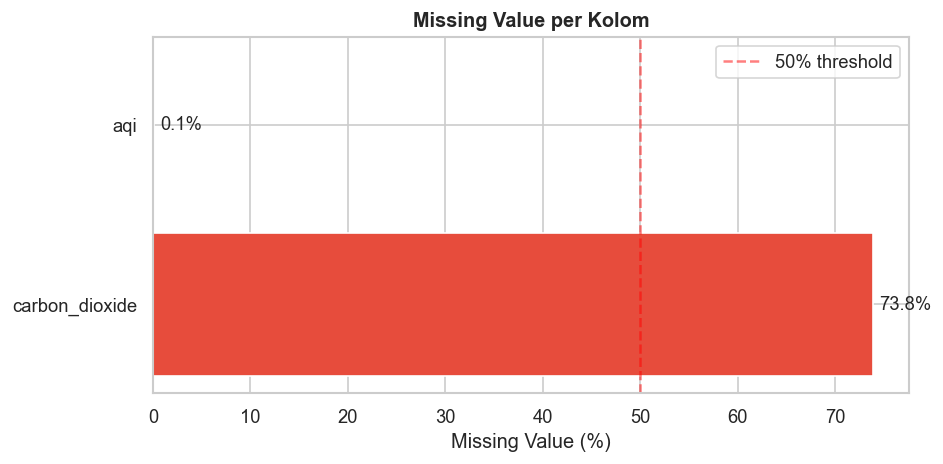

In [7]:
missing_df = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing (%)' : (df.isnull().mean() * 100).round(2)
}).sort_values('Missing (%)', ascending=False)

missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df.to_string())

# Chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing_df.index, missing_df['Missing (%)'],
               color=['#e74c3c' if v > 50 else '#f39c12' for v in missing_df['Missing (%)']])
ax.bar_label(bars, fmt='%.1f%%', padding=4)
ax.set_xlabel('Missing Value (%)')
ax.set_title('Missing Value per Kolom', fontweight='bold')
ax.axvline(50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
ax.legend()
plt.tight_layout()
plt.show()

### 3.3 Distribusi Kota & Cakupan Geografis

In [8]:
city_info = df.groupby(['city_id', 'city_name', 'lat', 'lon']).size().reset_index(name='record_count')
print(f'Jumlah kota unik : {city_info.shape[0]}')
print(f'Total record     : {df.shape[0]:,}')
print()
print('Distribusi Record per Kota')
print(city_info.sort_values('record_count', ascending=False).to_string(index=False))

Jumlah kota unik : 30
Total record     : 1,048,551

Distribusi Record per Kota
 city_id           city_name     lat     lon  record_count
 1185241               Dhaka 23.7104 90.4074        227016
 1185100               Dohār 23.5931 90.1425         28992
 1185186             Comilla 23.4619 91.1850         28992
 1185218           Gafargaon 24.4320 90.5585         28992
 1185224                Feni 23.0144 91.3966         28992
 1185247            Chilmāri 25.5561 89.6710         28992
 1185262           Bherāmāra 24.0245 88.9923         28992
 1185249        Chhāgalnāiya 23.0248 91.5109         28992
 1185254             Chhātak 25.0385 91.6696         28992
 1185260 Bhātpāra Abhaynagar 23.0147 89.4394         28992
 1185270           Bāndarban 22.1953 92.2195         28992
 1185263       Bhairab Bāzār 24.0524 90.9764         28992
 1185274          Baniachang 24.5186 91.3579         28992
 1185276            Bājitpur 24.2162 90.9500         28992
 1336134         Cox’s Bāzār 21.4397

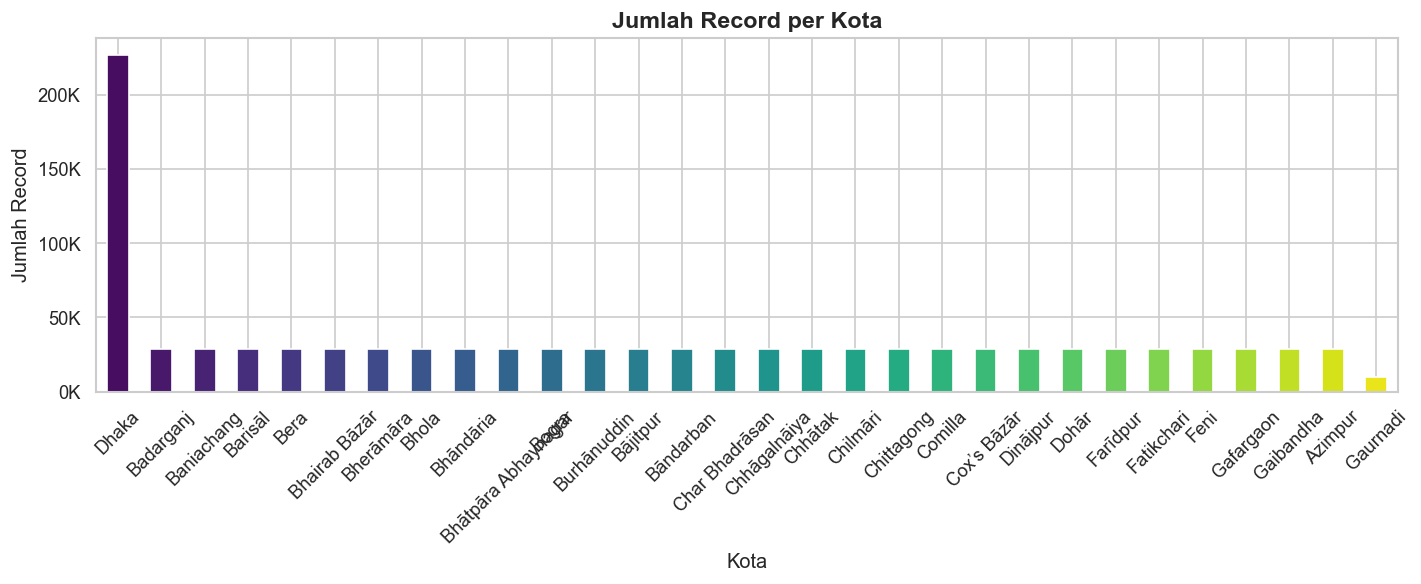

In [9]:
# Bar chart record per kota
city_counts = df['city_name'].value_counts()
fig, ax = plt.subplots(figsize=(12, 5))
city_counts.plot(kind='bar', ax=ax, color=sns.color_palette('viridis', len(city_counts)), edgecolor='white')
ax.set_title('Jumlah Record per Kota', fontweight='bold', fontsize=14)
ax.set_xlabel('Kota')
ax.set_ylabel('Jumlah Record')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 3.4 Analisis Time Range

Rentang Waktu Dataset
Dari  : 2000-01-01 00:00:00
Sampai: 2025-11-23 23:00:00
Durasi: 9458 hari


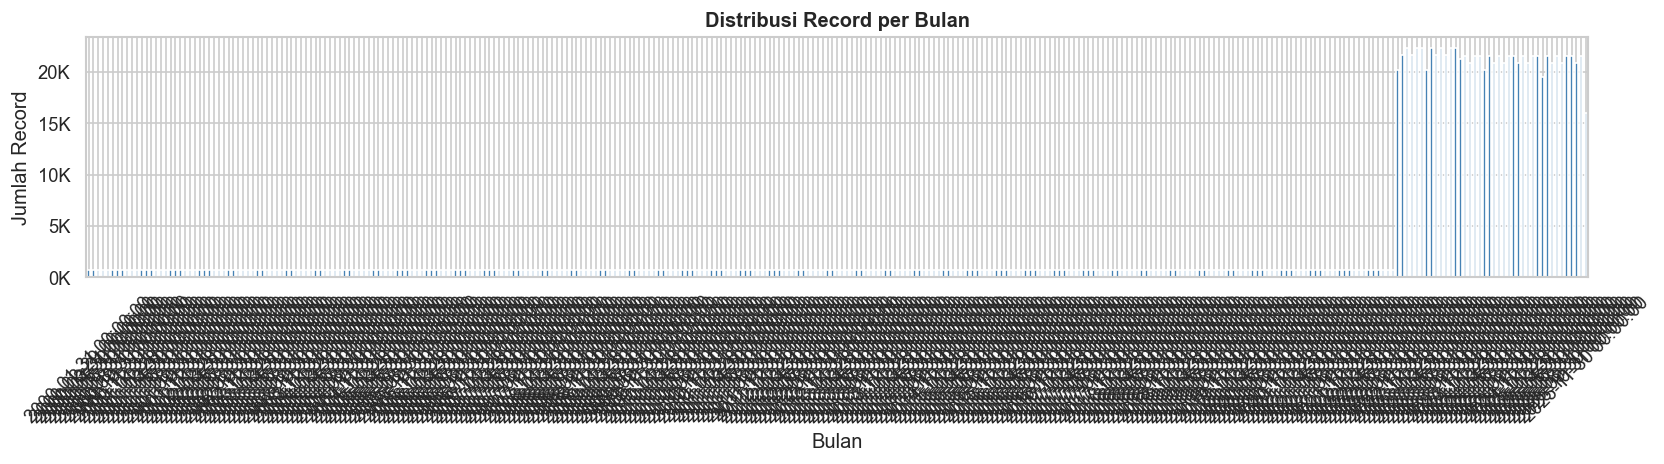

In [10]:
# Parse datetime untuk analisis
df_dt = df.copy()
df_dt['datetime'] = pd.to_datetime(df_dt['datetime'])

print('Rentang Waktu Dataset')
print(f"Dari  : {df_dt['datetime'].min()}")
print(f"Sampai: {df_dt['datetime'].max()}")
print(f"Durasi: {(df_dt['datetime'].max() - df_dt['datetime'].min()).days} hari")

# Distribusi per bulan
monthly_counts = df_dt.set_index('datetime').resample('ME').size()
fig, ax = plt.subplots(figsize=(14, 4))
monthly_counts.plot(ax=ax, kind='bar', color='steelblue', edgecolor='white')
ax.set_title('Distribusi Record per Bulan', fontweight='bold')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Record')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 3.5 Distribusi Fitur Polutan

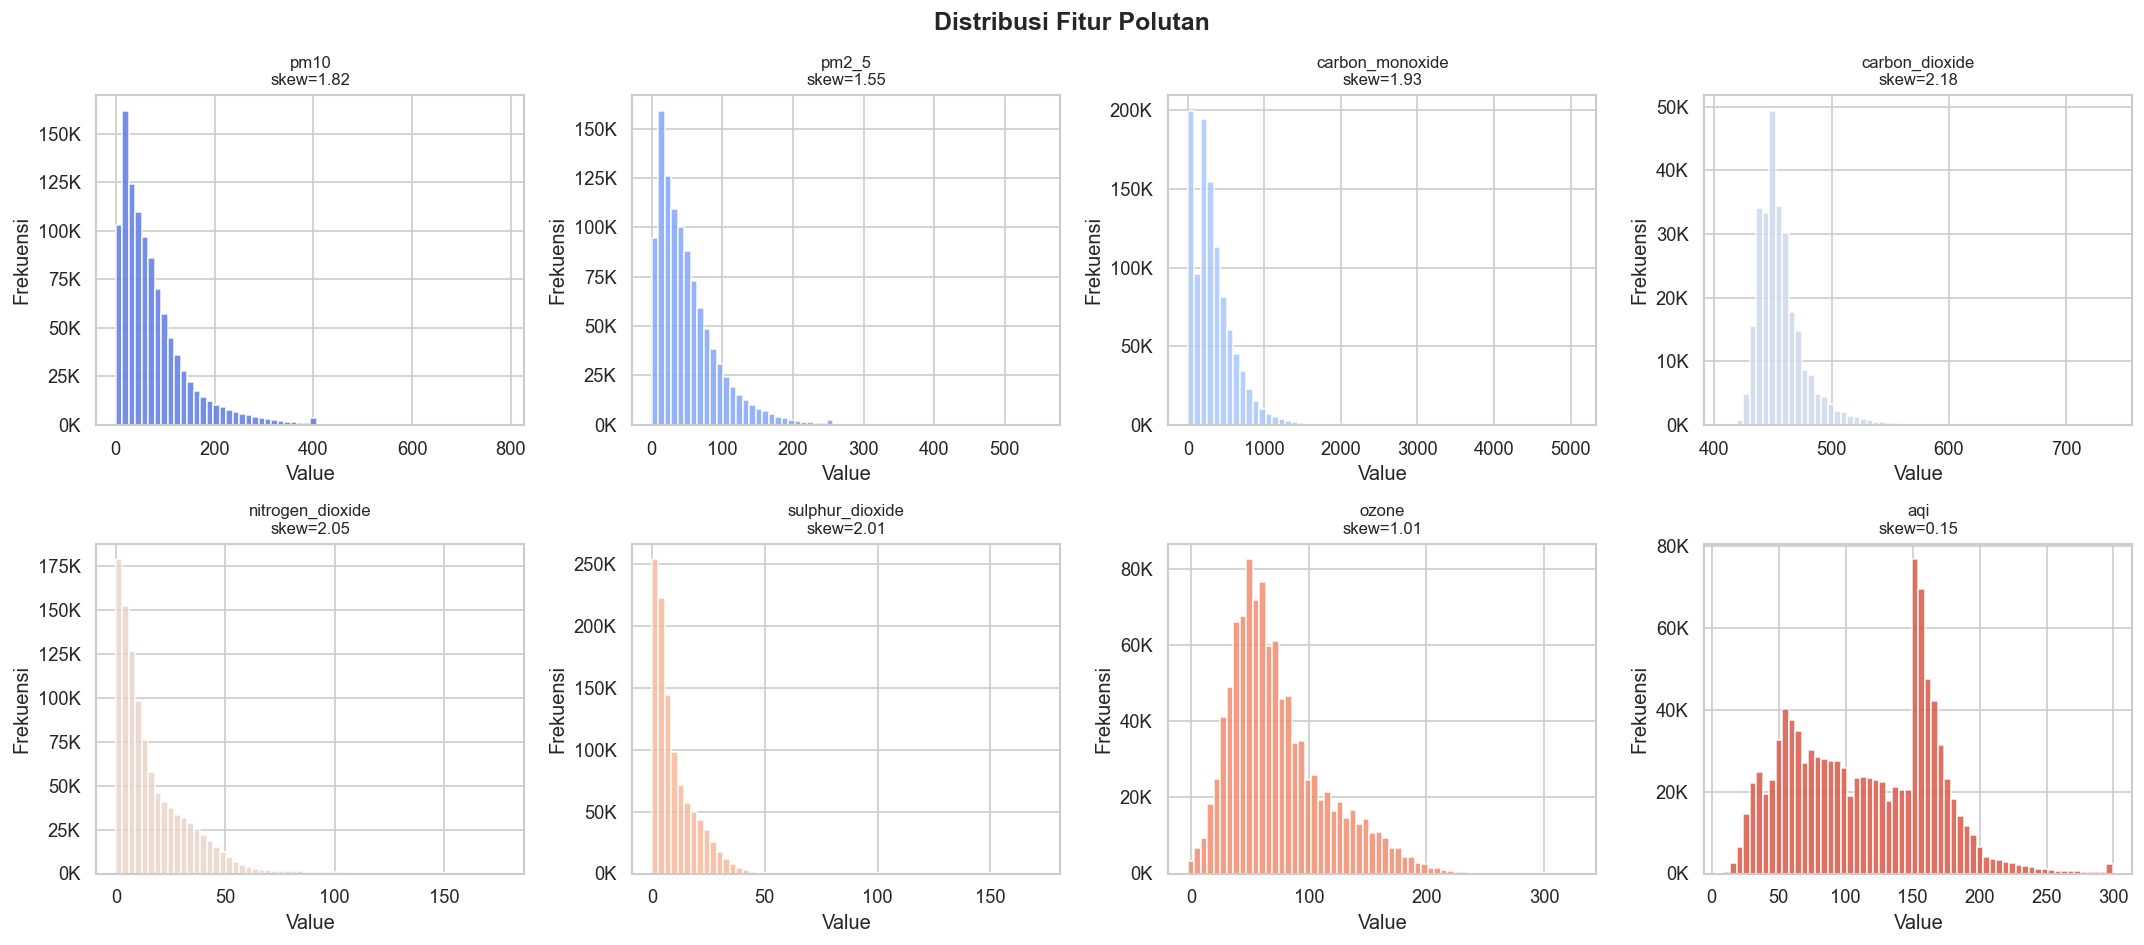

In [11]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

colors = sns.color_palette('coolwarm', 8)
for i, col in enumerate(pollutant_cols):
    data = df[col].dropna()
    axes[i].hist(data, bins=60, color=colors[i], edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}\nskew={skew(data):.2f}', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frekuensi')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

fig.suptitle('Distribusi Fitur Polutan', fontweight='bold', fontsize=15)
plt.tight_layout()
plt.show()

### 3.6 Deteksi Nilai Negatif (Physical Bounds Check)

In [12]:
print('Nilai Negatif per Kolom Polutan')
for col in pollutant_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f'  ⚠️  {col:20s}: {neg_count:,} nilai negatif ({neg_count/len(df)*100:.3f}%)')
    else:
        print(f'  ✅  {col:20s}: tidak ada nilai negatif')

Nilai Negatif per Kolom Polutan
  ✅  pm10                : tidak ada nilai negatif
  ✅  pm2_5               : tidak ada nilai negatif
  ✅  carbon_monoxide     : tidak ada nilai negatif
  ✅  carbon_dioxide      : tidak ada nilai negatif
  ⚠️  nitrogen_dioxide    : 1 nilai negatif (0.000%)
  ✅  sulphur_dioxide     : tidak ada nilai negatif
  ⚠️  ozone               : 11 nilai negatif (0.001%)
  ✅  aqi                 : tidak ada nilai negatif


### 3.7 Outlier Detection (IQR Method)

In [13]:
print('Deteksi Outlier (IQR Method)')
outlier_summary = {}
for col in pollutant_cols:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 3.0 * iqr
    upper = q3 + 3.0 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary[col] = {'Q1': q1, 'Q3': q3, 'IQR': iqr,
                            'Lower': lower, 'Upper': upper, 'Outliers': n_out,
                            'Outlier%': round(n_out/df[col].notna().sum()*100, 3)}
out_df = pd.DataFrame(outlier_summary).T
print(out_df[['Lower', 'Upper', 'Outliers', 'Outlier%']].to_string())

Deteksi Outlier (IQR Method)
                     Lower     Upper   Outliers  Outlier%
pm10             -194.5000  320.7000 10987.0000    1.0480
pm2_5            -132.8000  221.4000  5213.0000    0.4970
carbon_monoxide  -733.0000 1339.0000  6439.0000    0.6140
carbon_dioxide    384.0000  524.0000  3959.0000    1.4440
nitrogen_dioxide  -55.6000   84.4000  9611.0000    0.9170
sulphur_dioxide   -31.0000   48.1000  2398.0000    0.2290
ozone            -102.0000  241.0000   583.0000    0.0560
aqi              -199.7065  424.9420     0.0000    0.0000


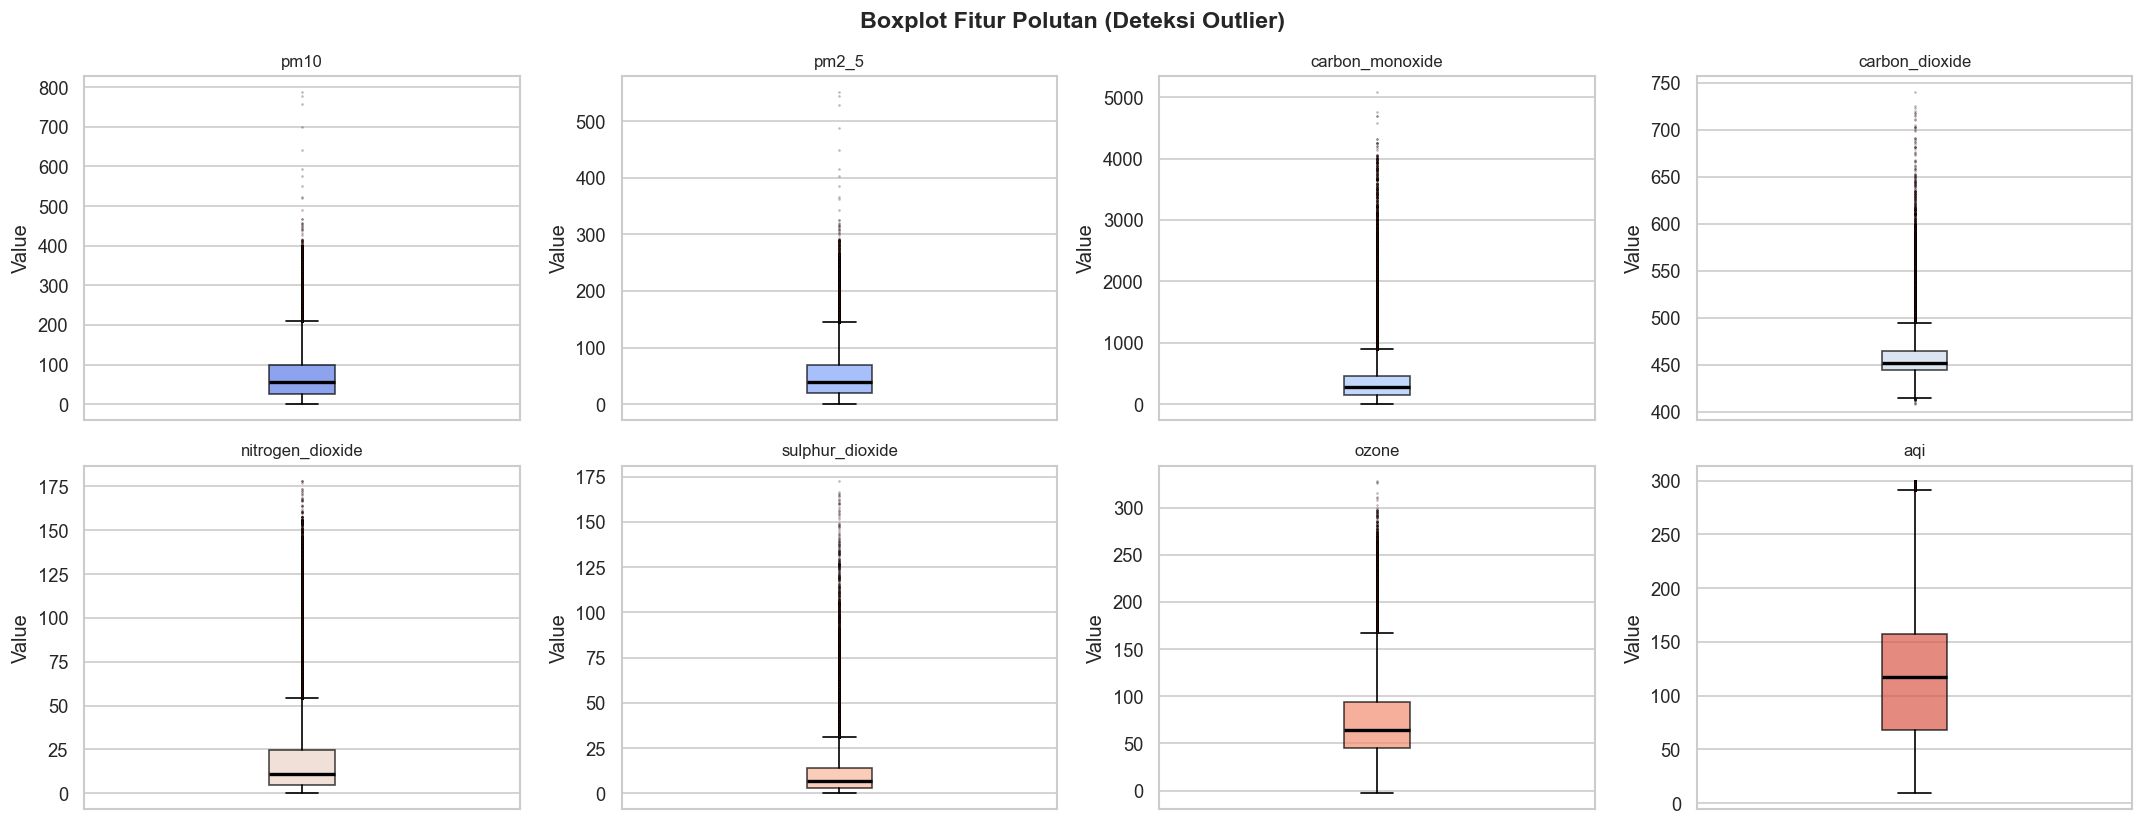

In [14]:
# Boxplot per polutan
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(pollutant_cols):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor=colors[i], alpha=0.7),
                    medianprops=dict(color='black', linewidth=2),
                    flierprops=dict(marker='.', markerfacecolor='red', markersize=1, alpha=0.3))
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Value')
    axes[i].set_xticks([])

fig.suptitle('Boxplot Fitur Polutan (Deteksi Outlier)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### 3.8 Korelasi Antar Fitur

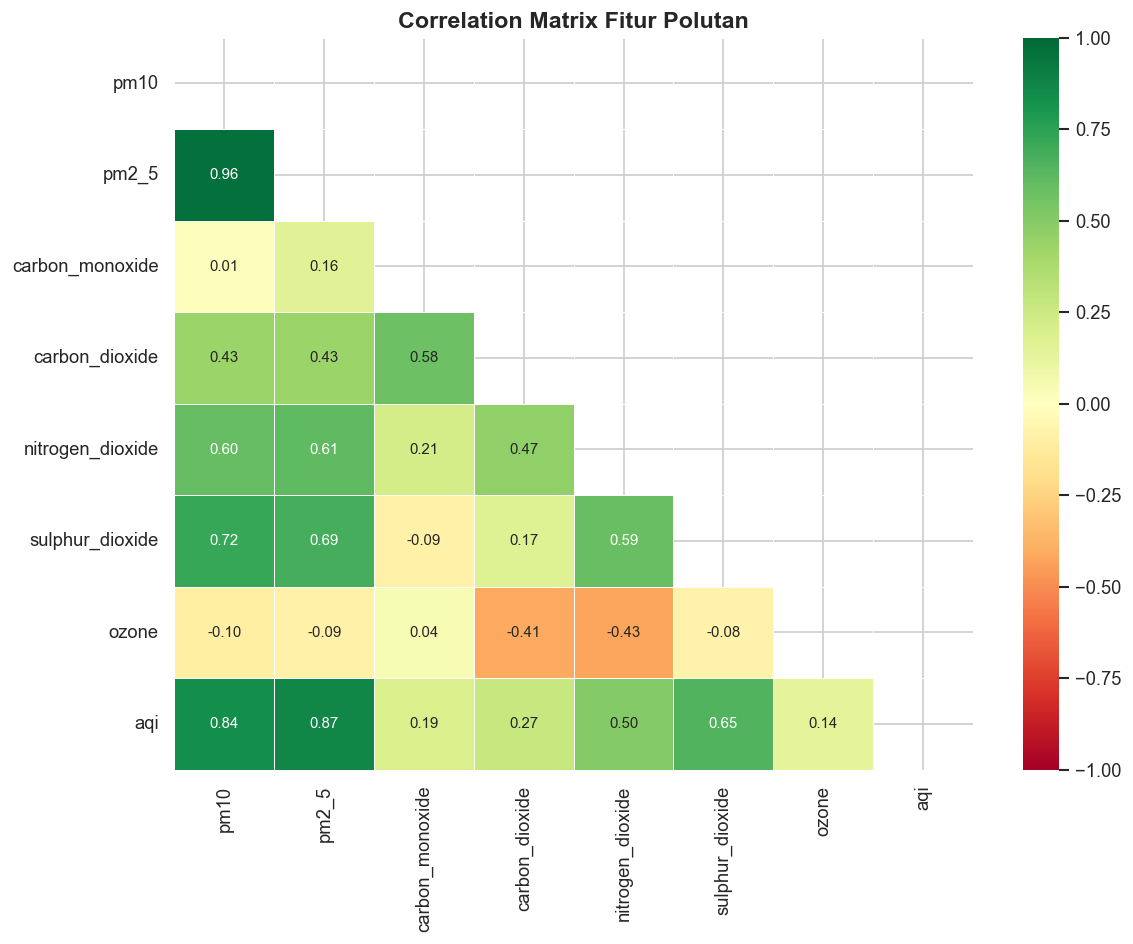


Korelasi dengan Target (AQI)
aqi                1.0000
pm2_5              0.8712
pm10               0.8387
sulphur_dioxide    0.6540
nitrogen_dioxide   0.5016
carbon_dioxide     0.2668
carbon_monoxide    0.1877
ozone              0.1375


In [15]:
corr_matrix = df[pollutant_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # sembunyikan atas diagonal
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, ax=ax, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix Fitur Polutan', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

# Korelasi dengan target AQI
print('\nKorelasi dengan Target (AQI)')
aqi_corr = df[pollutant_cols].corr()['aqi'].sort_values(ascending=False)
print(aqi_corr.to_string())

### 3.9 Tren AQI per Kota (Time Series)

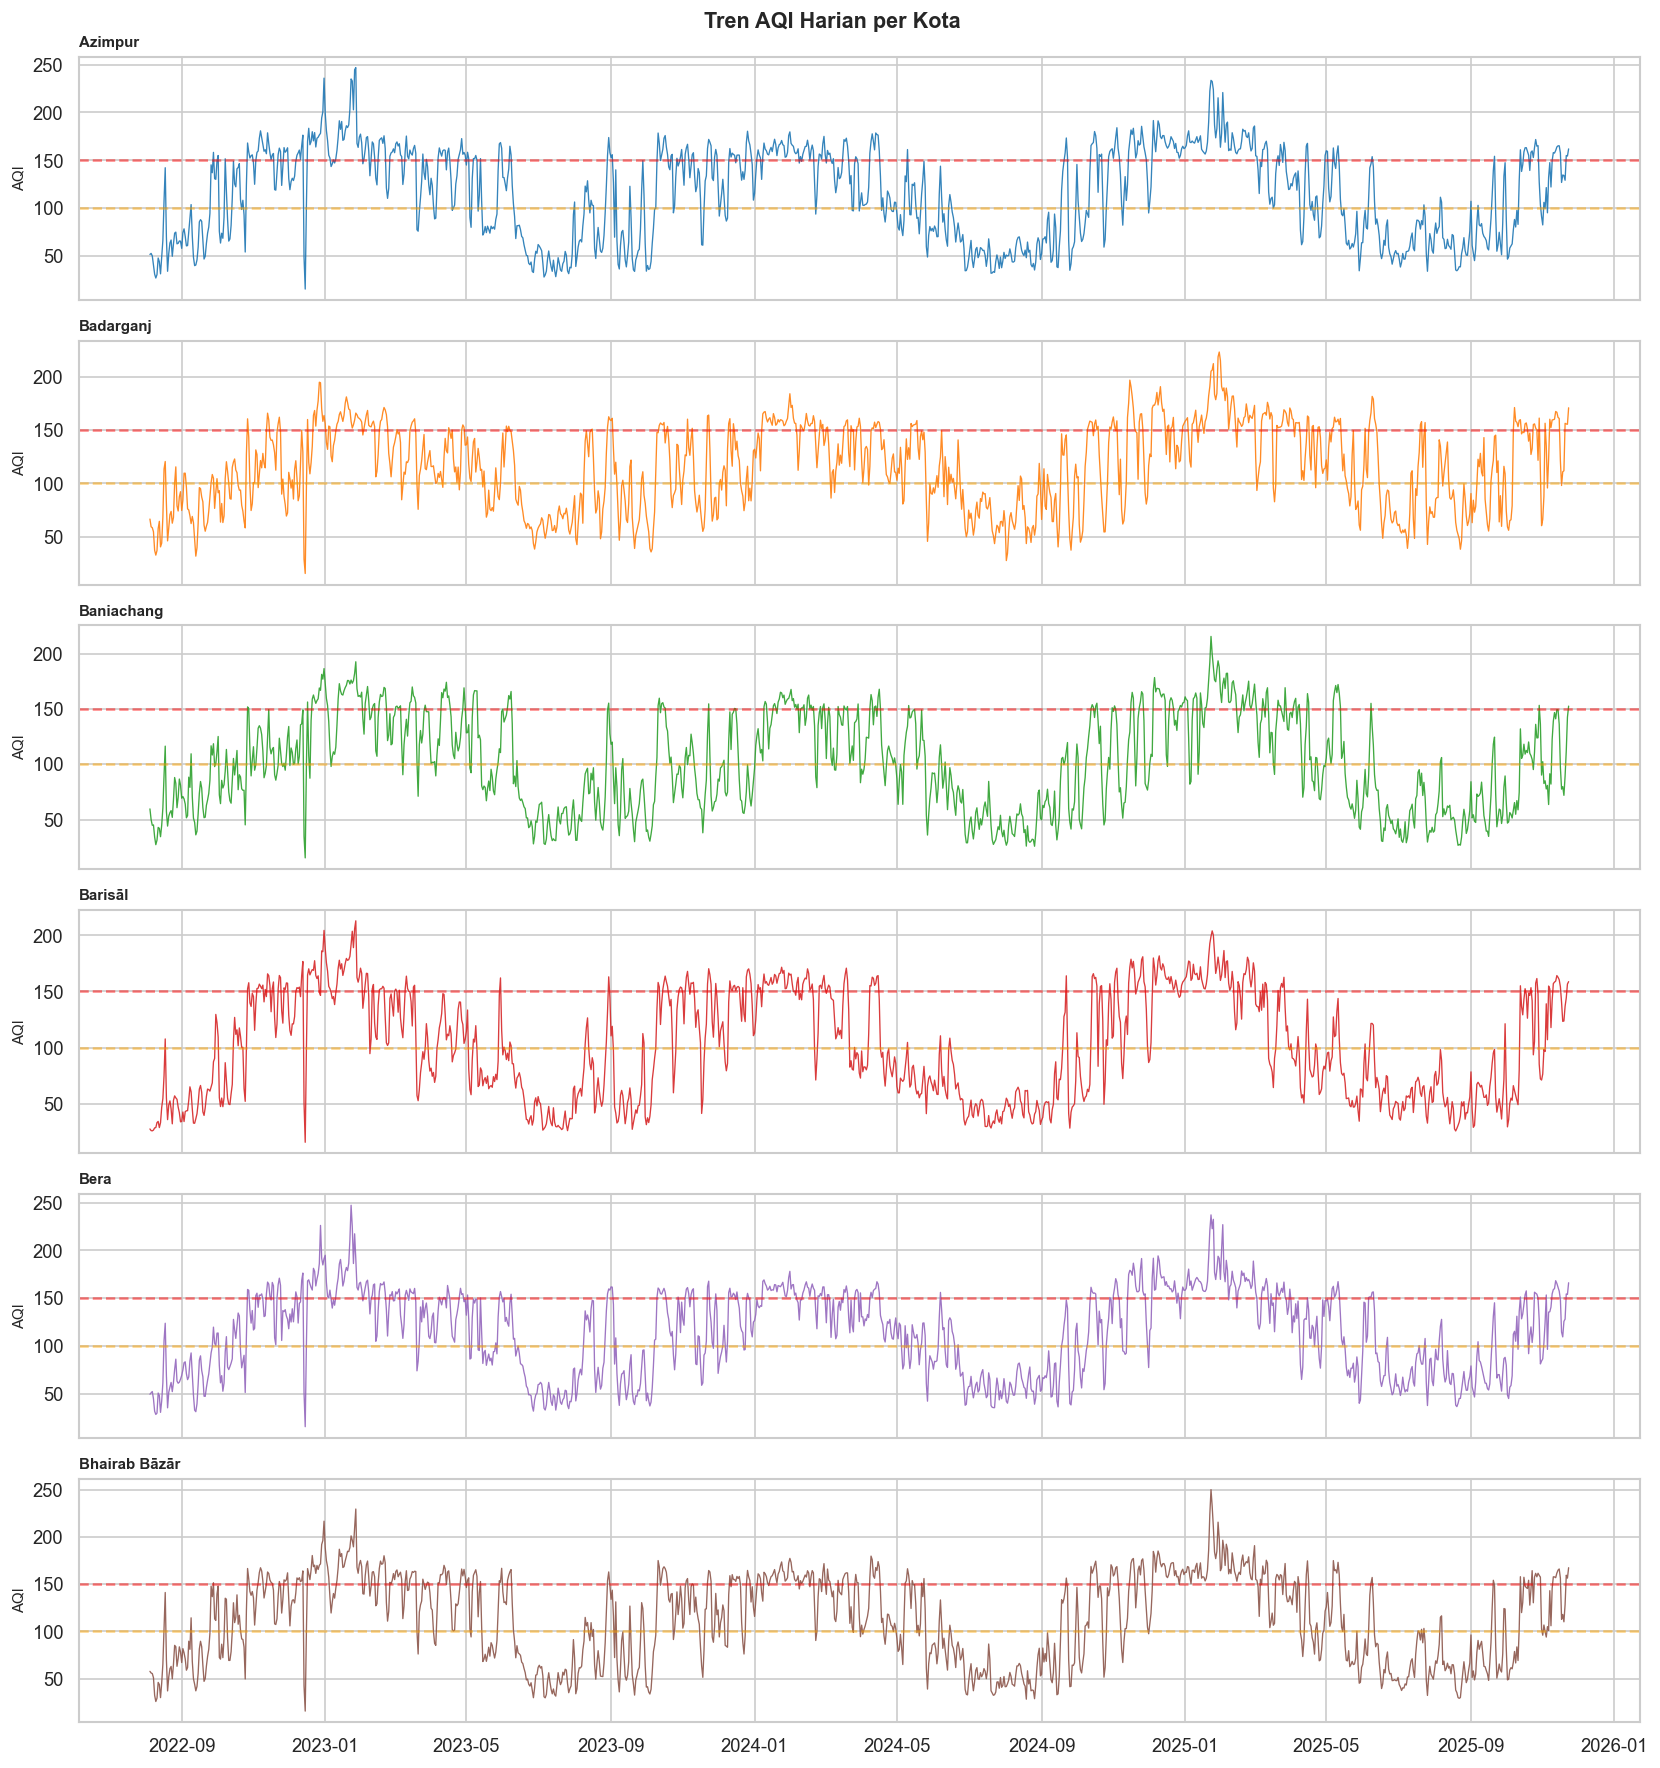

In [16]:
df_ts = df_dt.copy()
df_ts = df_ts.set_index('datetime')

# Rata-rata AQI harian per kota
daily_aqi = df_ts.groupby('city_name')['aqi'].resample('D').mean().reset_index()
cities = daily_aqi['city_name'].unique()[:6]
fig, axes = plt.subplots(len(cities), 1, figsize=(14, len(cities) * 2.5), sharex=True)

palette = sns.color_palette('tab10', len(cities))
for i, city in enumerate(cities):
    data_city = daily_aqi[daily_aqi['city_name'] == city]
    axes[i].plot(data_city['datetime'], data_city['aqi'],
                 color=palette[i], linewidth=0.8, alpha=0.9)
    axes[i].set_ylabel('AQI', fontsize=9)
    axes[i].set_title(city, fontsize=9, loc='left', fontweight='bold')
    axes[i].axhline(100, color='orange', linestyle='--', alpha=0.5)
    axes[i].axhline(150, color='red', linestyle='--', alpha=0.5)

fig.suptitle('Tren AQI Harian per Kota', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### 3.10 Pola Jam & Musiman (Hourly & Monthly Pattern)

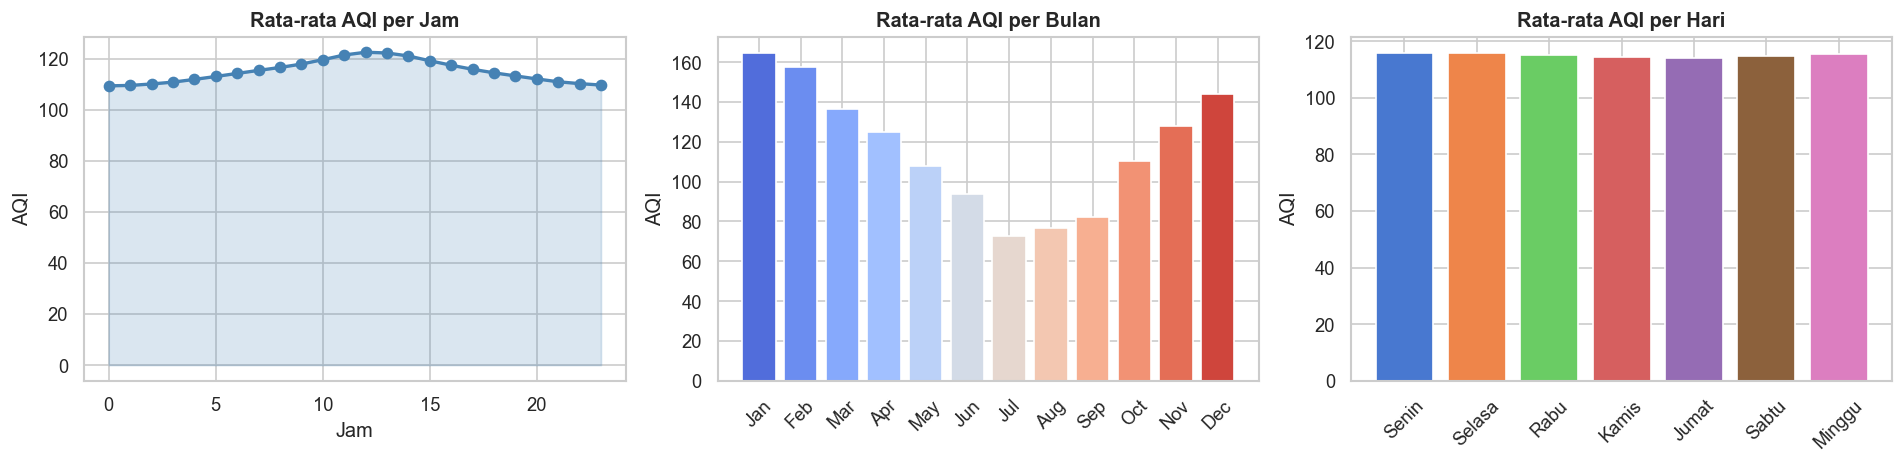

In [17]:
df_ts2 = df_dt.copy()
df_ts2['hour']  = df_ts2['datetime'].dt.hour
df_ts2['month'] = df_ts2['datetime'].dt.month
df_ts2['dow']   = df_ts2['datetime'].dt.dayofweek  # 0=Senin

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Pola per jam
hourly = df_ts2.groupby('hour')['aqi'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', color='steelblue', linewidth=2)
axes[0].fill_between(hourly.index, hourly.values, alpha=0.2, color='steelblue')
axes[0].set_title('Rata-rata AQI per Jam', fontweight='bold')
axes[0].set_xlabel('Jam')
axes[0].set_ylabel('AQI')

# Pola per bulan
monthly = df_ts2.groupby('month')['aqi'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(monthly.index, monthly.values, color=sns.color_palette('coolwarm', 12), edgecolor='white')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names, rotation=45)
axes[1].set_title('Rata-rata AQI per Bulan', fontweight='bold')
axes[1].set_ylabel('AQI')

# Pola per hari dalam seminggu
dow = df_ts2.groupby('dow')['aqi'].mean()
day_names = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
axes[2].bar(range(7), dow.values, color=sns.color_palette('muted', 7), edgecolor='white')
axes[2].set_xticks(range(7))
axes[2].set_xticklabels(day_names, rotation=45)
axes[2].set_title('Rata-rata AQI per Hari', fontweight='bold')
axes[2].set_ylabel('AQI')

plt.tight_layout()
plt.show()

### 3.11 Distribusi Kategori AQI

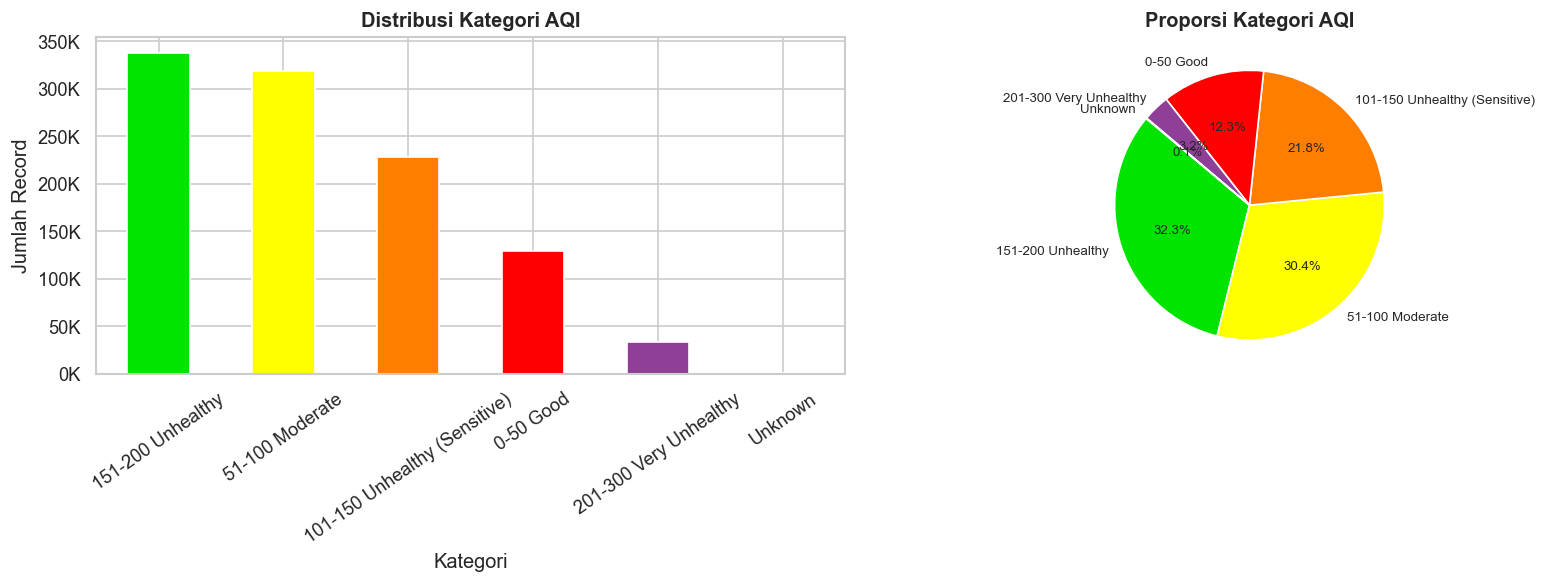

Distribusi Kategori AQI
aqi_category
151-200 Unhealthy                338240
51-100 Moderate                  318798
101-150 Unhealthy (Sensitive)    228281
0-50 Good                        128822
201-300 Very Unhealthy            33714
Unknown                             696


In [18]:
def aqi_category(aqi):
    if pd.isna(aqi):   return 'Unknown'
    elif aqi <= 50:    return '0-50 Good'
    elif aqi <= 100:   return '51-100 Moderate'
    elif aqi <= 150:   return '101-150 Unhealthy (Sensitive)'
    elif aqi <= 200:   return '151-200 Unhealthy'
    elif aqi <= 300:   return '201-300 Very Unhealthy'
    else:              return '301+ Hazardous'

df['aqi_category'] = df['aqi'].apply(aqi_category)
cat_counts = df['aqi_category'].value_counts()

aqi_colors = ['#00e400','#ffff00','#ff7e00','#ff0000','#8f3f97','#7e0023','#cccccc']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts.plot(kind='bar', ax=axes[0], color=aqi_colors[:len(cat_counts)], edgecolor='white')
axes[0].set_title('Distribusi Kategori AQI', fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Record')
axes[0].tick_params(axis='x', rotation=35)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

axes[1].pie(cat_counts.values, labels=cat_counts.index, colors=aqi_colors[:len(cat_counts)],
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 8})
axes[1].set_title('Proporsi Kategori AQI', fontweight='bold')

plt.tight_layout()
plt.show()

print('Distribusi Kategori AQI')
print(cat_counts.to_string())